# Neural Network Starter - ROGII Wellbore Geology Prediction

This notebook is a PyTorch starter for the **ROGII - Wellbore Geology Prediction** competition.

The task is to predict `tvt` (`True Vertical Thickness`) for the hidden/evaluation interval of each horizontal well. The visible `TVT_input` column gives the known interpreted TVT before the prediction start; after that point it becomes missing and we must infer the continuation.

This starter uses a compact **dilated 1D CNN / TCN** sequence model:

- Each horizontal well is treated as one sequence along `MD`.
- The model sees full-row features available at test time: trajectory, `GR`, `TVT_input` mask, baseline features, and Typewell GR alignment features.
- It predicts a residual over the final known `TVT_input` baseline.
- Loss is computed only on the hidden/evaluation zone, matching the submission target rows.
- Validation uses **GroupKFold by well ID**.
- Fold models are averaged for the final `submission.csv`.

## 1. Imports and Configuration

Set `FAST_DEBUG = True` manually or run with `FAST_DEBUG=1` in the environment for a quick smoke test. The default configuration runs a full 5-fold starter.

In [1]:
from pathlib import Path
from collections import defaultdict
import copy
import gc
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

RANDOM_STATE = 42
FAST_DEBUG = False

N_FOLDS = 2 if FAST_DEBUG else 5
MAX_TRAIN_WELLS = 24 if FAST_DEBUG else None
EPOCHS = 1 if FAST_DEBUG else 6
BATCH_SIZE = 4 if FAST_DEBUG else 6
HIDDEN_SIZE = 32 if FAST_DEBUG else 96
NUM_BLOCKS = 3 if FAST_DEBUG else 5
LEARNING_RATE = 2e-3
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

torch.backends.cudnn.benchmark = True

print("FAST_DEBUG:", FAST_DEBUG)
print("DEVICE:", DEVICE)
print("N_FOLDS:", N_FOLDS)
print("EPOCHS:", EPOCHS)
print("BATCH_SIZE:", BATCH_SIZE)

FAST_DEBUG: False
DEVICE: cuda
N_FOLDS: 5
EPOCHS: 6
BATCH_SIZE: 6


## 2. Locate Data

The helper below works on Kaggle and with a local extracted copy of the competition data.

In [2]:
def find_data_root():
    candidates = [
        Path("/kaggle/input/competitions/rogii-wellbore-geology-prediction"),
        Path.cwd(),
    ]
    candidates.extend(Path.cwd().parents)

    for root in candidates:
        if (root / "train").is_dir() and (root / "sample_submission.csv").is_file():
            return root.resolve()
    raise FileNotFoundError("Could not find train/ and sample_submission.csv")

DATA_ROOT = find_data_root()
TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR = DATA_ROOT / "test"
SAMPLE_SUB_PATH = DATA_ROOT / "sample_submission.csv"

print("DATA_ROOT:", DATA_ROOT)
print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR:", TEST_DIR)

DATA_ROOT: /kaggle/input/competitions/rogii-wellbore-geology-prediction
TRAIN_DIR: /kaggle/input/competitions/rogii-wellbore-geology-prediction/train
TEST_DIR: /kaggle/input/competitions/rogii-wellbore-geology-prediction/test


In [3]:
def well_id_from_path(path):
    return Path(path).name.split("__", 1)[0]

train_horizontal_paths = sorted(TRAIN_DIR.glob("*__horizontal_well.csv"))
test_horizontal_paths = sorted(TEST_DIR.glob("*__horizontal_well.csv"))

if MAX_TRAIN_WELLS is not None:
    train_horizontal_paths = train_horizontal_paths[:MAX_TRAIN_WELLS]

sample_sub = pd.read_csv(SAMPLE_SUB_PATH)
sample_sub["well_id"] = sample_sub["id"].str.rsplit("_", n=1).str[0]
sample_sub["row_index"] = sample_sub["id"].str.rsplit("_", n=1).str[1].astype(int)

print(f"Training horizontal wells used: {len(train_horizontal_paths)}")
print(f"Visible test horizontal wells:  {len(test_horizontal_paths)}")
print(f"Sample submission rows:        {len(sample_sub)}")
display(sample_sub.head())

Training horizontal wells used: 773
Visible test horizontal wells:  3
Sample submission rows:        14151


,id,tvt,well_id,row_index
0,000d7d20_1442,0.0,000d7d20,1442
1,000d7d20_1443,0.0,000d7d20,1443
2,000d7d20_1444,0.0,000d7d20,1444
3,000d7d20_1445,0.0,000d7d20,1445
4,000d7d20_1446,0.0,000d7d20,1446


## 3. Feature Engineering

The model predicts a residual from the strong flat last-known baseline:

`baseline_tvt = last_known_tvt`

The original slope-continuation values (from notebook version 3) are still kept as features:

- `baseline_tvt_all_slope`
- `baseline_tvt_recent_slope`
- `slope_tvt_md_all`
- `slope_tvt_md_recent`

All other feature engineering and NN settings are kept the same as `nn.ipynb`.

Training ignores formation-surface columns such as `ANCC`, `ASTNU`, etc. Those are training-only fields and are not available in the real test set.


In [4]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def robust_slope(x, y, default=0.0):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return default
    x = x[mask]
    y = y[mask]
    if np.nanstd(x) < 1e-6:
        return default
    return float(np.polyfit(x, y, 1)[0])


def safe_interp(x, xp, fp):
    x = np.asarray(x, dtype=np.float64)
    xp = np.asarray(xp, dtype=np.float64)
    fp = np.asarray(fp, dtype=np.float64)
    mask = np.isfinite(xp) & np.isfinite(fp)
    if mask.sum() < 2:
        return np.full_like(x, np.nan, dtype=np.float64)
    order = np.argsort(xp[mask])
    xp = xp[mask][order]
    fp = fp[mask][order]
    return np.interp(x, xp, fp, left=np.nan, right=np.nan)


def make_test_row_map(submission):
    row_map = defaultdict(list)
    for well_id, row_idx in zip(submission["well_id"], submission["row_index"]):
        row_map[well_id].append(int(row_idx))
    return {k: np.array(v, dtype=np.int64) for k, v in row_map.items()}


def load_typewell(well_id, split):
    base = TRAIN_DIR if split == "train" else TEST_DIR
    path = base / f"{well_id}__typewell.csv"
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame({"TVT": [], "GR": []})

In [5]:
def build_sequence(horizontal_path, split="train", test_row_map=None):
    well_id = well_id_from_path(horizontal_path)
    h = pd.read_csv(horizontal_path)
    tw = load_typewell(well_id, split)
    n = len(h)
    row_index = np.arange(n, dtype=np.int64)

    known_mask = h["TVT_input"].notna().to_numpy()
    missing_mask = h["TVT_input"].isna().to_numpy()
    if split == "train":
        target_mask = missing_mask & h["TVT"].notna().to_numpy()
    else:
        target_mask = np.zeros(n, dtype=bool)
        if test_row_map is not None and well_id in test_row_map:
            valid_idx = test_row_map[well_id]
            valid_idx = valid_idx[(valid_idx >= 0) & (valid_idx < n)]
            target_mask[valid_idx] = True
        else:
            target_mask = missing_mask.copy()

    known = h.loc[known_mask].copy()
    if len(known) == 0:
        known = h.head(1).copy()
        known["TVT_input"] = np.nan

    first_missing = np.flatnonzero(missing_mask)
    ps_idx = int(first_missing[0]) if len(first_missing) else int(n)
    last_known = known.iloc[-1]

    ps_md = float(last_known.get("MD", np.nan))
    ps_x = float(last_known.get("X", np.nan))
    ps_y = float(last_known.get("Y", np.nan))
    ps_z = float(last_known.get("Z", np.nan))
    ps_gr = float(last_known.get("GR", np.nan))
    last_known_tvt = float(last_known.get("TVT_input", np.nan))

    slope_all = robust_slope(known["MD"], known["TVT_input"])
    recent = known.tail(min(200, len(known)))
    slope_recent = robust_slope(recent["MD"], recent["TVT_input"], default=slope_all)
    slope_z_recent = robust_slope(recent["Z"], recent["TVT_input"])

    md = h["MD"].astype(float).to_numpy()
    x = h["X"].astype(float).to_numpy()
    y = h["Y"].astype(float).to_numpy()
    z = h["Z"].astype(float).to_numpy()
    gr_raw = h["GR"].astype(float)
    gr_filled = gr_raw.interpolate(limit_direction="both")
    if gr_filled.isna().all():
        gr_filled = pd.Series(np.zeros(n), index=h.index, dtype=float)
    else:
        gr_filled = gr_filled.fillna(gr_filled.mean())

    tvt_input = h["TVT_input"].astype(float)
    tvt_input_filled = tvt_input.ffill().bfill().fillna(last_known_tvt)

    md_from_ps = md - ps_md
    x_from_ps = x - ps_x
    y_from_ps = y - ps_y
    z_from_ps = z - ps_z
    xy_dist_from_ps = np.sqrt(x_from_ps ** 2 + y_from_ps ** 2)
    xyz_dist_from_ps = np.sqrt(xy_dist_from_ps ** 2 + z_from_ps ** 2)

    baseline_all = last_known_tvt + slope_all * md_from_ps
    baseline_recent = last_known_tvt + slope_recent * md_from_ps
    baseline = np.full(n, last_known_tvt, dtype=np.float64)

    feature_dict = {
        "MD": md,
        "X": x,
        "Y": y,
        "Z": z,
        "GR_filled": gr_filled.to_numpy(dtype=float),
        "GR_missing": gr_raw.isna().astype(float).to_numpy(),
        "row_index": row_index.astype(float),
        "row_frac": row_index / max(n - 1, 1),
        "known_tvt_mask": known_mask.astype(float),
        "TVT_input_filled": tvt_input_filled.to_numpy(dtype=float),
        "TVT_input_delta_last": tvt_input_filled.to_numpy(dtype=float) - last_known_tvt,
        "last_known_tvt": np.full(n, last_known_tvt),
        "known_tvt_range": np.full(n, known["TVT_input"].max() - known["TVT_input"].min()),
        "known_tvt_std": np.full(n, known["TVT_input"].std()),
        "known_gr_mean": np.full(n, gr_raw[known_mask].mean()),
        "known_gr_std": np.full(n, gr_raw[known_mask].std()),
        "last_known_gr": np.full(n, ps_gr),
        "slope_tvt_md_all": np.full(n, slope_all),
        "slope_tvt_md_recent": np.full(n, slope_recent),
        "slope_tvt_z_recent": np.full(n, slope_z_recent),
        "row_from_ps": row_index.astype(float) - ps_idx,
        "md_from_ps": md_from_ps,
        "x_from_ps": x_from_ps,
        "y_from_ps": y_from_ps,
        "z_from_ps": z_from_ps,
        "xy_dist_from_ps": xy_dist_from_ps,
        "xyz_dist_from_ps": xyz_dist_from_ps,
        "baseline_tvt": baseline,
        "baseline_tvt_all_slope": baseline_all,
        "baseline_tvt_recent_slope": baseline_recent,
        "GR_minus_last_known": gr_filled.to_numpy(dtype=float) - ps_gr,
    }

    for window in [11, 51, 151]:
        roll = gr_filled.rolling(window=window, center=True, min_periods=max(2, window // 5))
        feature_dict[f"GR_roll_mean_{window}"] = roll.mean().bfill().ffill().to_numpy(dtype=float)
        feature_dict[f"GR_roll_std_{window}"] = roll.std().bfill().ffill().fillna(0).to_numpy(dtype=float)
    feature_dict["GR_diff_1"] = gr_filled.diff(1).fillna(0).to_numpy(dtype=float)
    feature_dict["GR_diff_10"] = gr_filled.diff(10).fillna(0).to_numpy(dtype=float)

    if {"TVT", "GR"}.issubset(tw.columns) and len(tw) > 1:
        tw_tvt = tw["TVT"].astype(float)
        tw_gr = tw["GR"].astype(float)
        tw_gr_at_baseline = safe_interp(baseline, tw_tvt, tw_gr)
        tw_gr_at_last = safe_interp(np.array([last_known_tvt]), tw_tvt, tw_gr)[0]
        feature_dict["typewell_tvt_min"] = np.full(n, tw_tvt.min())
        feature_dict["typewell_tvt_max"] = np.full(n, tw_tvt.max())
        feature_dict["typewell_tvt_range"] = np.full(n, tw_tvt.max() - tw_tvt.min())
        feature_dict["typewell_gr_mean"] = np.full(n, tw_gr.mean())
        feature_dict["typewell_gr_std"] = np.full(n, tw_gr.std())
        feature_dict["tw_gr_at_baseline_tvt"] = tw_gr_at_baseline
        feature_dict["tw_gr_at_last_known_tvt"] = np.full(n, tw_gr_at_last)
        feature_dict["GR_minus_tw_baseline"] = gr_filled.to_numpy(dtype=float) - tw_gr_at_baseline
        feature_dict["GR_minus_tw_last_known"] = gr_filled.to_numpy(dtype=float) - tw_gr_at_last
    else:
        for col in [
            "typewell_tvt_min", "typewell_tvt_max", "typewell_tvt_range",
            "typewell_gr_mean", "typewell_gr_std", "tw_gr_at_baseline_tvt",
            "tw_gr_at_last_known_tvt", "GR_minus_tw_baseline", "GR_minus_tw_last_known",
        ]:
            feature_dict[col] = np.full(n, np.nan)

    feature_names = list(feature_dict)
    X = np.vstack([feature_dict[c] for c in feature_names]).T.astype(np.float32)
    baseline = baseline.astype(np.float32)

    if split == "train":
        y_tvt = h["TVT"].astype(float).to_numpy(dtype=np.float32)
        y_residual = y_tvt - baseline
    else:
        y_tvt = np.full(n, np.nan, dtype=np.float32)
        y_residual = np.full(n, np.nan, dtype=np.float32)

    return {
        "well_id": well_id,
        "feature_names": feature_names,
        "X": X,
        "baseline": baseline,
        "y_tvt": y_tvt,
        "y_residual": y_residual.astype(np.float32),
        "target_mask": target_mask.astype(bool),
        "row_index": row_index,
    }

## 4. Build Sequences

In [6]:
train_sequences = []
feature_names = None

for i, path in enumerate(train_horizontal_paths, start=1):
    seq = build_sequence(path, split="train")
    if feature_names is None:
        feature_names = seq["feature_names"]
    train_sequences.append(seq)
    if i % 100 == 0:
        print(f"Processed {i}/{len(train_horizontal_paths)} train wells")

print(f"Training sequences: {len(train_sequences)}")
print(f"Features: {len(feature_names)}")
print(feature_names)
print("Total training rows:", sum(len(s["row_index"]) for s in train_sequences))
print("Total target rows:", sum(int(s["target_mask"].sum()) for s in train_sequences))

Processed 100/773 train wells
Processed 200/773 train wells
Processed 300/773 train wells
Processed 400/773 train wells
Processed 500/773 train wells
Processed 600/773 train wells
Processed 700/773 train wells
Training sequences: 773
Features: 48
['MD', 'X', 'Y', 'Z', 'GR_filled', 'GR_missing', 'row_index', 'row_frac', 'known_tvt_mask', 'TVT_input_filled', 'TVT_input_delta_last', 'last_known_tvt', 'known_tvt_range', 'known_tvt_std', 'known_gr_mean', 'known_gr_std', 'last_known_gr', 'slope_tvt_md_all', 'slope_tvt_md_recent', 'slope_tvt_z_recent', 'row_from_ps', 'md_from_ps', 'x_from_ps', 'y_from_ps', 'z_from_ps', 'xy_dist_from_ps', 'xyz_dist_from_ps', 'baseline_tvt', 'baseline_tvt_all_slope', 'baseline_tvt_recent_slope', 'GR_minus_last_known', 'GR_roll_mean_11', 'GR_roll_std_11', 'GR_roll_mean_51', 'GR_roll_std_51', 'GR_roll_mean_151', 'GR_roll_std_151', 'GR_diff_1', 'GR_diff_10', 'typewell_tvt_min', 'typewell_tvt_max', 'typewell_tvt_range', 'typewell_gr_mean', 'typewell_gr_std', 'tw_gr

In [7]:
summary = pd.DataFrame({
    "well_id": [s["well_id"] for s in train_sequences],
    "rows": [len(s["row_index"]) for s in train_sequences],
    "target_rows": [int(s["target_mask"].sum()) for s in train_sequences],
    "baseline_rmse": [rmse(s["y_tvt"][s["target_mask"]], s["baseline"][s["target_mask"]]) for s in train_sequences],
})
display(summary.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T)
display(summary.head())

,count,mean,std,min,5%,25%,50%,75%,95%,max
rows,773.0,6587.652005,1311.463547,2058.000000,4652.200000,5706.000000,6576.000000,7388.000000,8614.200000,12141.000000
target_rows,773.0,4895.199224,1301.178409,407.000000,2947.400000,4044.000000,4840.000000,5694.000000,6918.400000,10052.000000
baseline_rmse,773.0,12.812479,8.899496,1.115995,3.858931,7.100749,10.665402,15.811449,29.010747,70.639008


,well_id,rows,target_rows,baseline_rmse
0,000d7d20,5278,3836,7.454535
1,00bbac68,7559,6014,15.263057
2,00e12e8b,6384,4301,7.924623
3,015fe0d2,5950,4296,23.154655
4,01869cd4,6850,5557,10.618408


## 5. Dataset, Scalers, and Model

In [8]:
def compute_feature_scaler(sequences):
    n_features = sequences[0]["X"].shape[1]
    sums = np.zeros(n_features, dtype=np.float64)
    sums_sq = np.zeros(n_features, dtype=np.float64)
    counts = np.zeros(n_features, dtype=np.float64)

    for seq in sequences:
        X = seq["X"].astype(np.float64)
        mask = np.isfinite(X)
        X0 = np.where(mask, X, 0.0)
        sums += X0.sum(axis=0)
        sums_sq += (X0 ** 2).sum(axis=0)
        counts += mask.sum(axis=0)

    counts = np.maximum(counts, 1.0)
    mean = sums / counts
    var = sums_sq / counts - mean ** 2
    std = np.sqrt(np.maximum(var, 1e-6))
    return mean.astype(np.float32), std.astype(np.float32)


def compute_target_scaler(sequences):
    vals = []
    for seq in sequences:
        m = seq["target_mask"]
        vals.append(seq["y_residual"][m])
    vals = np.concatenate(vals).astype(np.float32)
    mean = float(np.nanmean(vals))
    std = float(np.nanstd(vals) + 1e-6)
    return mean, std


def transform_features(X, mean, std):
    X = (X - mean) / std
    return np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)


class WellSequenceDataset(Dataset):
    def __init__(self, sequences, feature_mean, feature_std, y_mean, y_std):
        self.sequences = sequences
        self.feature_mean = feature_mean
        self.feature_std = feature_std
        self.y_mean = y_mean
        self.y_std = y_std

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]
        X = transform_features(seq["X"], self.feature_mean, self.feature_std)
        y = (seq["y_residual"] - self.y_mean) / self.y_std
        y = np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
        return {
            "X": torch.tensor(X, dtype=torch.float32),
            "y": torch.tensor(y, dtype=torch.float32),
            "target_mask": torch.tensor(seq["target_mask"], dtype=torch.bool),
        }


def collate_wells(batch):
    batch_size = len(batch)
    max_len = max(item["X"].shape[0] for item in batch)
    n_features = batch[0]["X"].shape[1]

    X = torch.zeros(batch_size, max_len, n_features, dtype=torch.float32)
    y = torch.zeros(batch_size, max_len, dtype=torch.float32)
    target_mask = torch.zeros(batch_size, max_len, dtype=torch.bool)

    for i, item in enumerate(batch):
        length = item["X"].shape[0]
        X[i, :length] = item["X"]
        y[i, :length] = item["y"]
        target_mask[i, :length] = item["target_mask"]

    return X, y, target_mask

In [9]:
class ResidualBlock(nn.Module):
    def __init__(self, channels, kernel_size=5, dilation=1, dropout=0.10):
        super().__init__()
        padding = dilation * (kernel_size - 1) // 2
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, padding=padding, dilation=dilation),
            nn.BatchNorm1d(channels),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Conv1d(channels, channels, kernel_size, padding=padding, dilation=dilation),
            nn.BatchNorm1d(channels),
            nn.SiLU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return x + self.block(x)


class TCNResidualModel(nn.Module):
    def __init__(self, n_features, hidden_size=96, num_blocks=5, dropout=0.10):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Conv1d(n_features, hidden_size, kernel_size=1),
            nn.BatchNorm1d(hidden_size),
            nn.SiLU(),
        )
        self.blocks = nn.Sequential(*[
            ResidualBlock(hidden_size, kernel_size=5, dilation=2 ** i, dropout=dropout)
            for i in range(num_blocks)
        ])
        self.head = nn.Sequential(
            nn.Conv1d(hidden_size, hidden_size // 2, kernel_size=1),
            nn.SiLU(),
            nn.Conv1d(hidden_size // 2, 1, kernel_size=1),
        )

    def forward(self, x):
        # x: batch, seq_len, features
        x = x.transpose(1, 2)
        x = self.input_proj(x)
        x = self.blocks(x)
        x = self.head(x).squeeze(1)
        return x


def masked_mse(pred, target, mask):
    if mask.sum() == 0:
        return None
    diff = pred[mask] - target[mask]
    return torch.mean(diff ** 2)

## 6. Well-Grouped K-Fold Validation

Rows from the same well are highly correlated, so validation is grouped by `well_id`.

In [10]:
def predict_sequences(model, sequences, feature_mean, feature_std, y_mean, y_std, device=DEVICE):
    model.eval()
    rows = []
    with torch.no_grad():
        for seq in sequences:
            X = transform_features(seq["X"], feature_mean, feature_std)
            x_tensor = torch.tensor(X[None, :, :], dtype=torch.float32, device=device)
            pred_scaled = model(x_tensor).cpu().numpy()[0]
            pred_residual = pred_scaled * y_std + y_mean
            pred_tvt = seq["baseline"] + pred_residual

            m = seq["target_mask"]
            rows.append(pd.DataFrame({
                "well_id": seq["well_id"],
                "row_index": seq["row_index"][m],
                "actual_tvt": seq["y_tvt"][m],
                "baseline_tvt": seq["baseline"][m],
                "pred_tvt": pred_tvt[m],
            }))
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def train_fold(fold, train_seqs, valid_seqs):
    feature_mean, feature_std = compute_feature_scaler(train_seqs)
    y_mean, y_std = compute_target_scaler(train_seqs)

    train_ds = WellSequenceDataset(train_seqs, feature_mean, feature_std, y_mean, y_std)
    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        collate_fn=collate_wells,
        pin_memory=torch.cuda.is_available(),
    )

    model = TCNResidualModel(
        n_features=len(feature_names),
        hidden_size=HIDDEN_SIZE,
        num_blocks=NUM_BLOCKS,
        dropout=0.10,
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(EPOCHS, 1))

    best_rmse = np.inf
    best_state = None
    history = []

    for epoch in range(1, EPOCHS + 1):
        model.train()
        losses = []

        for X, y, target_mask in train_loader:
            X = X.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            target_mask = target_mask.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            pred = model(X)
            loss = masked_mse(pred, y, target_mask)
            if loss is None:
                continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            losses.append(float(loss.detach().cpu()))

        scheduler.step()

        valid_pred = predict_sequences(model, valid_seqs, feature_mean, feature_std, y_mean, y_std)
        valid_rmse = rmse(valid_pred["actual_tvt"], valid_pred["pred_tvt"])
        valid_baseline_rmse = rmse(valid_pred["actual_tvt"], valid_pred["baseline_tvt"])
        train_loss = float(np.mean(losses)) if losses else np.nan

        history.append({
            "fold": fold,
            "epoch": epoch,
            "train_loss": train_loss,
            "valid_baseline_rmse": valid_baseline_rmse,
            "valid_nn_rmse": valid_rmse,
        })

        print(
            f"Fold {fold} epoch {epoch:02d} | "
            f"train_loss {train_loss:.5f} | "
            f"baseline RMSE {valid_baseline_rmse:.5f} | "
            f"NN RMSE {valid_rmse:.5f}"
        )

        if valid_rmse < best_rmse:
            best_rmse = valid_rmse
            best_state = copy.deepcopy(model.state_dict())

    if best_state is not None:
        model.load_state_dict(best_state)

    best_valid_pred = predict_sequences(model, valid_seqs, feature_mean, feature_std, y_mean, y_std)
    return model, feature_mean, feature_std, y_mean, y_std, pd.DataFrame(history), best_valid_pred

In [11]:
well_ids = np.array([seq["well_id"] for seq in train_sequences])
gkf = GroupKFold(n_splits=N_FOLDS)

fold_models = []
fold_scalers = []
oof_parts = []
history_parts = []
fold_rows = []

for fold, (train_idx, valid_idx) in enumerate(gkf.split(well_ids, groups=well_ids), start=1):
    print(f"\n===== Fold {fold}/{N_FOLDS} =====")
    train_seqs = [train_sequences[i] for i in train_idx]
    valid_seqs = [train_sequences[i] for i in valid_idx]
    print(f"Train wells: {len(train_seqs)} | Valid wells: {len(valid_seqs)}")

    model, f_mean, f_std, y_mean, y_std, hist, valid_pred = train_fold(fold, train_seqs, valid_seqs)

    fold_baseline_rmse = rmse(valid_pred["actual_tvt"], valid_pred["baseline_tvt"])
    fold_nn_rmse = rmse(valid_pred["actual_tvt"], valid_pred["pred_tvt"])
    fold_rows.append({
        "fold": fold,
        "valid_rows": len(valid_pred),
        "valid_wells": len(valid_seqs),
        "baseline_rmse": fold_baseline_rmse,
        "nn_rmse": fold_nn_rmse,
        "improvement": fold_baseline_rmse - fold_nn_rmse,
    })

    fold_models.append(model)
    fold_scalers.append((f_mean, f_std, y_mean, y_std))
    history_parts.append(hist)
    oof_parts.append(valid_pred.assign(fold=fold))

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

cv = pd.DataFrame(fold_rows)
history = pd.concat(history_parts, ignore_index=True)
oof = pd.concat(oof_parts, ignore_index=True)

display(cv)
print(f"OOF baseline RMSE: {rmse(oof['actual_tvt'], oof['baseline_tvt']):.5f}")
print(f"OOF NN RMSE:       {rmse(oof['actual_tvt'], oof['pred_tvt']):.5f}")
print(f"Mean fold RMSE:    {cv['nn_rmse'].mean():.5f} +/- {cv['nn_rmse'].std():.5f}")


===== Fold 1/5 =====
Train wells: 618 | Valid wells: 155
Fold 1 epoch 01 | train_loss 1.04744 | baseline RMSE 16.91354 | NN RMSE 16.95843
Fold 1 epoch 02 | train_loss 0.98314 | baseline RMSE 16.91354 | NN RMSE 16.00639
Fold 1 epoch 03 | train_loss 0.95855 | baseline RMSE 16.91354 | NN RMSE 16.31147
Fold 1 epoch 04 | train_loss 0.96816 | baseline RMSE 16.91354 | NN RMSE 15.91146
Fold 1 epoch 05 | train_loss 0.91088 | baseline RMSE 16.91354 | NN RMSE 15.86530
Fold 1 epoch 06 | train_loss 0.88012 | baseline RMSE 16.91354 | NN RMSE 15.93512

===== Fold 2/5 =====
Train wells: 618 | Valid wells: 155
Fold 2 epoch 01 | train_loss 1.02050 | baseline RMSE 17.47310 | NN RMSE 17.75177
Fold 2 epoch 02 | train_loss 0.95941 | baseline RMSE 17.47310 | NN RMSE 17.27265
Fold 2 epoch 03 | train_loss 0.91585 | baseline RMSE 17.47310 | NN RMSE 21.71151
Fold 2 epoch 04 | train_loss 0.90880 | baseline RMSE 17.47310 | NN RMSE 19.79908
Fold 2 epoch 05 | train_loss 0.88032 | baseline RMSE 17.47310 | NN RMSE 22

,fold,valid_rows,valid_wells,baseline_rmse,nn_rmse,improvement
0,1,780457,155,16.913535,15.865296,1.048239
1,2,741878,155,17.473105,17.272653,0.200452
2,3,752995,155,14.417591,14.215263,0.202329
3,4,740432,154,16.336815,16.068470,0.268345
4,5,768227,154,14.154501,14.067336,0.087165


OOF baseline RMSE: 15.90987
OOF NN RMSE:       15.53440
Mean fold RMSE:    15.49780 +/- 1.35111


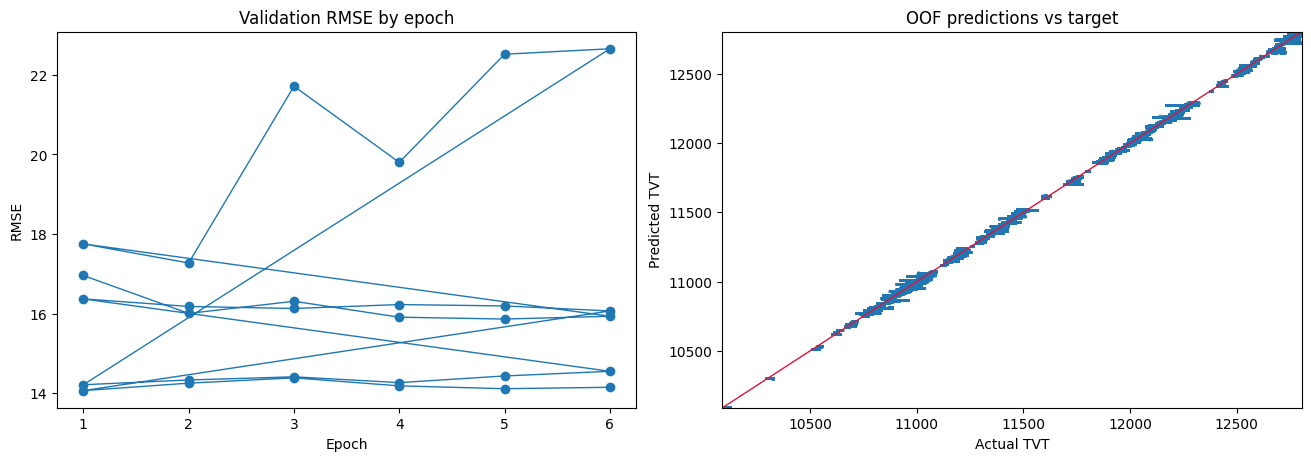

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

axes[0].plot(history["epoch"], history["valid_nn_rmse"], marker="o", lw=1)
axes[0].set_title("Validation RMSE by epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("RMSE")

lo = float(np.nanpercentile(oof["actual_tvt"], 1))
hi = float(np.nanpercentile(oof["actual_tvt"], 99))
axes[1].scatter(oof["actual_tvt"], oof["pred_tvt"], s=1, alpha=0.08)
axes[1].plot([lo, hi], [lo, hi], color="crimson", lw=1)
axes[1].set_xlim(lo, hi)
axes[1].set_ylim(lo, hi)
axes[1].set_title("OOF predictions vs target")
axes[1].set_xlabel("Actual TVT")
axes[1].set_ylabel("Predicted TVT")
plt.show()

## 7. Build Test Sequences and Predict

Fold models are averaged for the final submission.

In [13]:
test_sequences = []
for i, path in enumerate(test_horizontal_paths, start=1):
    test_sequences.append(build_sequence(path, split="test", test_row_map=None))
    if i % 50 == 0:
        print(f"Processed {i}/{len(test_horizontal_paths)} test wells")

print(f"Test sequences: {len(test_sequences)}")
print("Target rows requested:", sum(int(s["target_mask"].sum()) for s in test_sequences))

Test sequences: 3
Target rows requested: 14151


In [14]:
def predict_test_average(models, scalers, sequences):
    pred_sum = {}
    pred_count = defaultdict(int)

    for fold, (model, scaler) in enumerate(zip(models, scalers), start=1):
        f_mean, f_std, y_mean, y_std = scaler
        model.eval()
        with torch.no_grad():
            for seq in sequences:
                X = transform_features(seq["X"], f_mean, f_std)
                x_tensor = torch.tensor(X[None, :, :], dtype=torch.float32, device=DEVICE)
                pred_scaled = model(x_tensor).cpu().numpy()[0]
                pred_residual = pred_scaled * y_std + y_mean
                pred_tvt = seq["baseline"] + pred_residual

                m = seq["target_mask"]
                for row_idx, tvt in zip(seq["row_index"][m], pred_tvt[m]):
                    pred_id = f"{seq['well_id']}_{int(row_idx)}"
                    pred_sum[pred_id] = pred_sum.get(pred_id, 0.0) + float(tvt)
                    pred_count[pred_id] += 1
        print(f"Predicted test with fold model {fold}")

    return {k: pred_sum[k] / pred_count[k] for k in pred_sum}

pred_map = predict_test_average(fold_models, fold_scalers, test_sequences)
print("Predicted ids:", len(pred_map))

Predicted test with fold model 1
Predicted test with fold model 2
Predicted test with fold model 3
Predicted test with fold model 4
Predicted test with fold model 5
Predicted ids: 14151


## 8. Save Submission

In [15]:
submission = pd.DataFrame({"id": list(pred_map.keys()), "tvt": list(pred_map.values())})
submission["tvt"] = pd.to_numeric(submission["tvt"], errors="coerce")
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")
print(submission.shape)
display(submission.head())
display(submission["tvt"].describe())

Saved submission.csv
(14151, 2)


,id,tvt
0,000d7d20_1442,11748.551758
1,000d7d20_1443,11748.499609
2,000d7d20_1444,11748.460547
3,000d7d20_1445,11748.318555
4,000d7d20_1446,11748.303906


count    14151.000000
mean     11907.544446
std        278.637716
min      11603.329687
25%      11605.137305
50%      11749.048047
75%      12225.259375
max      12227.451172
Name: tvt, dtype: float64